# Model Leaderboard

Ranks training runs by a chosen metric. Each run must have a `summary.toml` file
(written automatically by `train.jl` when `write_summary = true`).

Edit the **Settings** cell below to point at your output directories, filter by
quantity, and choose a sort metric.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
using AIHydroPoints
using DataFrames

  Activating project at `~/deepblack/src/AIHydroPoints.jl.git_claude`


## Settings

In [2]:
settings = Dict(
    # One directory or a list of directories to scan recursively for summary.toml files.
    "root_dirs"  => joinpath(@__DIR__, "training_output"),

    # Keep only runs whose out_quantities overlaps this list. Set to nothing for all.
    "quantities" => ["surge"],

    # Column to sort by (must exist in summary.toml).
    "sort_by"    => "rmse_testing",

    # true = lowest value first (best for RMSE), false = highest first.
    "ascending"  => true,
)

Dict{String, Any} with 4 entries:
  "root_dirs"  => "/home/verlaan/deepblack/src/AIHydroPoints.jl.git_claude/expe…
  "sort_by"    => "rmse_testing"
  "ascending"  => true
  "quantities" => ["surge"]

## Load and rank runs

In [3]:
lb = load_leaderboard(
    settings["root_dirs"];
    quantities = settings["quantities"],
)

if isempty(lb)
    @warn "No runs found. Check root_dirs and quantities filter."
else
    lb = sort_leaderboard(lb, settings["sort_by"]; ascending=settings["ascending"])
    lb[!, :rank] = 1:nrow(lb)
    select!(lb, :rank, :)
    println("Found $(nrow(lb)) run(s).")
end

Found 2 run(s).


## Leaderboard table

Key summary columns. The `run_dir` column gives the full path to each run's output directory.

In [4]:
display_cols = [:rank, :runid, :model_name, :rmse_testing,
                :n_params, :train_time_s, :description]
available = [c for c in display_cols if c in propertynames(lb)]
lb[!, available]

Row,rank,runid,model_name,rmse_testing,n_params,train_time_s,description
,Int64,String,String,Float64,Int64,Float64,String
1,1,example,LinearSurgeModel,0.112226,2165,11.2,Linear surge model trained on 2011 ERA5 wind stress and Schureman surge.
2,2,example,ConvSurgeModel,0.115922,5461,47.0,Convolutional surge model trained on 2011 ERA5 wind stress and Schureman surge.


## All summary fields

Full table including any extra split metrics (e.g. `rmse_validation`, `rmse_storm_andrea_2012`).

In [5]:
lb

Row,rank,runid,model_name,out_quantities,rmse_testing,n_params,train_time_s,description,run_dir,predict_time_storm_andrea_2012_s,predict_time_testing_s,rmse_storm_andrea_2012
,Int64,String,String,String,Float64,Int64,Float64,String,String,Float64,Float64,Float64
1,1,example,LinearSurgeModel,surge,0.112226,2165,11.2,Linear surge model trained on 2011 ERA5 wind stress and Schureman surge.,/home/verlaan/deepblack/src/AIHydroPoints.jl.git_claude/experiments/training_output/example_LinearSurgeModel,0.043,0.021,0.278556
2,2,example,ConvSurgeModel,surge,0.115922,5461,47.0,Convolutional surge model trained on 2011 ERA5 wind stress and Schureman surge.,/home/verlaan/deepblack/src/AIHydroPoints.jl.git_claude/experiments/training_output/example_ConvSurgeModel,0.168,0.089,0.264285


## Export to CSV

## Export to PNG (via PrettyTables + Chromium)

Renders the key-columns table as styled HTML, then converts to PNG using headless Chromium.
Requires `chromium` to be installed (included in `pixi.toml`).

31796 bytes written to file /home/verlaan/deepblack/src/AIHydroPoints.jl.git_claude/experiments/leaderboard.png


Saved to /home/verlaan/deepblack/src/AIHydroPoints.jl.git_claude/experiments/leaderboard.png



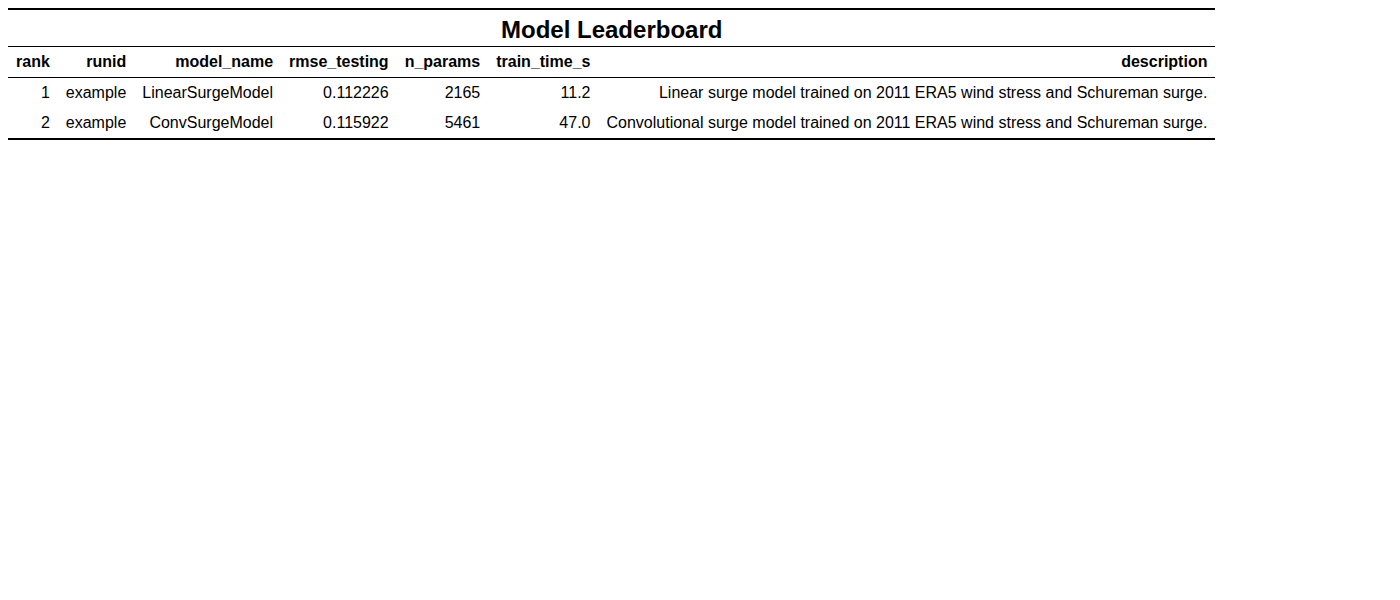

In [6]:
using PrettyTables

display_df = lb[!, available]  # same columns as the table above

html_path = joinpath(@__DIR__, "leaderboard.html")
png_path  = joinpath(@__DIR__, "leaderboard.png")

open(html_path, "w") do io
    pretty_table(io, display_df;
        backend       = :html,
        stand_alone   = true,
        title         = "Model Leaderboard",
        column_labels = string.(available),
    )
end

run(`chromium --headless --screenshot=$png_path --window-size=1400,600 $html_path`)
println("Saved to $png_path")

using Base64
img_b64 = base64encode(read(png_path))
display(MIME("text/html"), "<img src=\"data:image/png;base64,$img_b64\"/>")

In [7]:
using CSV
output_path = joinpath(@__DIR__, "leaderboard.csv")
CSV.write(output_path, lb)
println("Saved to $output_path")

Saved to /home/verlaan/deepblack/src/AIHydroPoints.jl.git_claude/experiments/leaderboard.csv
